# Оценка вероятности того, что пациент выживет


## 1. Разведочный анализ данных

## 1. Импорт библиотек

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import missingno as msno
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Настройка стиля графиков
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
sns.set_palette('Set2')

print('Библиотеки загружены.')

Библиотеки загружены.


## 2. Загрузка данных

In [3]:
df = pd.read_csv('dataset.csv')
print(f'Датасет загружен из файла. Размер: {df.shape}')

Датасет загружен из файла. Размер: (91713, 85)


## 3. Первичный осмотр данных

In [4]:
print(f'Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов')

Размер датасета: 91713 строк, 85 столбцов


In [5]:
# Первые 5 строк
df.head()

,encounter_id,patient_id,hospital_id,age,bmi,elective_surgery,ethnicity,gender,height,icu_admit_source,...,diabetes_mellitus,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis,apache_3j_bodysystem,apache_2_bodysystem,Unnamed: 83,hospital_death
0,66154,25312,118,68.0,22.73,0,Caucasian,M,180.3,Floor,...,1.0,0.0,0.0,0.0,0.0,0.0,Sepsis,Cardiovascular,NaN,0
1,114252,59342,81,77.0,27.42,0,Caucasian,F,160.0,Floor,...,1.0,0.0,0.0,0.0,0.0,0.0,Respiratory,Respiratory,NaN,0
2,119783,50777,118,25.0,31.95,0,Caucasian,F,172.7,Accident & Emergency,...,0.0,0.0,0.0,0.0,0.0,0.0,Metabolic,Metabolic,NaN,0
3,79267,46918,118,81.0,22.64,1,Caucasian,F,165.1,Operating Room / Recovery,...,0.0,0.0,0.0,0.0,0.0,0.0,Cardiovascular,Cardiovascular,NaN,0
4,92056,34377,33,19.0,NaN,0,Caucasian,M,188.0,Accident & Emergency,...,0.0,0.0,0.0,0.0,0.0,0.0,Trauma,Trauma,NaN,0


In [6]:
# Типы данных и непустые значения
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91713 entries, 0 to 91712
Data columns (total 85 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   encounter_id                   91713 non-null  int64  
 1   patient_id                     91713 non-null  int64  
 2   hospital_id                    91713 non-null  int64  
 3   age                            87485 non-null  float64
 4   bmi                            88284 non-null  float64
 5   elective_surgery               91713 non-null  int64  
 6   ethnicity                      90318 non-null  object 
 7   gender                         91688 non-null  object 
 8   height                         90379 non-null  float64
 9   icu_admit_source               91601 non-null  object 
 10  icu_id                         91713 non-null  int64  
 11  icu_stay_type                  91713 non-null  object 
 12  icu_type                       91713 non-null 

In [7]:
# Базовая описательная статистика
df.describe().T

,count,mean,std,min,25%,50%,75%,max
encounter_id,91713.0,65606.079280,37795.088538,1.000000,32852.000000,65665.000000,98342.000000,131051.00000
patient_id,91713.0,65537.131464,37811.252183,1.000000,32830.000000,65413.000000,98298.000000,131051.00000
hospital_id,91713.0,105.669262,62.854406,2.000000,47.000000,109.000000,161.000000,204.00000
age,87485.0,62.309516,16.775119,16.000000,52.000000,65.000000,75.000000,89.00000
bmi,88284.0,29.185818,8.275142,14.844926,23.641975,27.654655,32.930206,67.81499
...,...,...,...,...,...,...,...,...
leukemia,90998.0,0.007066,0.083763,0.000000,0.000000,0.000000,0.000000,1.00000
lymphoma,90998.0,0.004132,0.064148,0.000000,0.000000,0.000000,0.000000,1.00000
solid_tumor_with_metastasis,90998.0,0.020638,0.142169,0.000000,0.000000,0.000000,0.000000,1.00000
Unnamed: 83,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
# Проверка дубликатов
n_duplicates = df.duplicated().sum()
n_patient_dups = df.duplicated(subset=['patient_id']).sum() if 'patient_id' in df.columns else 'н/д'

print(f'Полных дубликатов строк: {n_duplicates}')
print(f'Дубликатов по patient_id: {n_patient_dups}')

# Столбец Unnamed: 83 — служебный, удаляем
if 'Unnamed: 83' in df.columns:
    print(f"\nСтолбец 'Unnamed: 83': {df['Unnamed: 83'].notna().sum()} непустых значений → удаляем")
    df.drop(columns=['Unnamed: 83'], inplace=True)

Полных дубликатов строк: 0
Дубликатов по patient_id: 0

Столбец 'Unnamed: 83': 0 непустых значений → удаляем


## 4. Анализ целевой переменной `hospital_death`

Распределение целевой переменной:
                Количество  Процент (%)
hospital_death                         
0                    83798        91.37
1                     7915         8.63


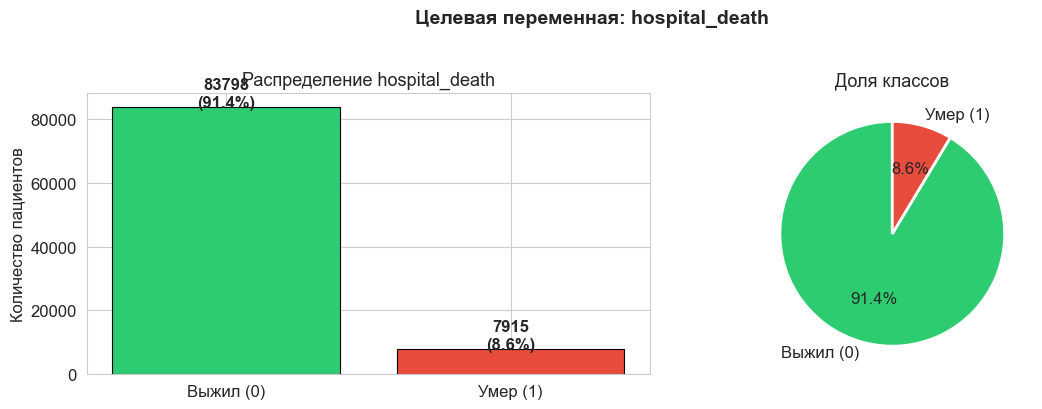

Дисбаланс классов: при моделировании использовать SMOTE, class_weight или другие техники


In [15]:
target = 'hospital_death'
counts = df[target].value_counts()
pct = df[target].value_counts(normalize=True) * 100

print('Распределение целевой переменной:')
print(pd.DataFrame({'Количество': counts, 'Процент (%)': pct.round(2)}))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(['Выжил (0)', 'Умер (1)'], counts.values, color=colors, edgecolor='black', linewidth=0.8)
for i, (cnt, p) in enumerate(zip(counts.values, pct.values)):
    axes[0].text(i, cnt + 50, f'{cnt}\n({p:.1f}%)', ha='center', fontweight='bold')
axes[0].set_title('Распределение hospital_death', fontsize=13)
axes[0].set_ylabel('Количество пациентов')

# Pie chart
axes[1].pie(counts.values, labels=['Выжил (0)', 'Умер (1)'],
            colors=colors, autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Доля классов', fontsize=13)

plt.suptitle('Целевая переменная: hospital_death', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

if pct.min() < 20:
    print('Дисбаланс классов: при моделировании использовать SMOTE, class_weight или другие техники')

## 5. Анализ пропущенных значений

In [16]:
# Таблица пропусков
missing = pd.DataFrame({
    'Кол-во пропусков': df.isnull().sum(),
    'Процент (%)': (df.isnull().sum() / len(df) * 100).round(2)
})
missing = missing[missing['Кол-во пропусков'] > 0].sort_values('Процент (%)', ascending=False)

print(f'Столбцов с пропусками: {len(missing)} из {df.shape[1]}')
print('\nТаблица пропусков (только столбцы с пропусками):')
display(missing)

Столбцов с пропусками: 74 из 84

Таблица пропусков (только столбцы с пропусками):


,Кол-во пропусков,Процент (%)
d1_potassium_max,9585,10.45
d1_potassium_min,9585,10.45
h1_mbp_noninvasive_max,9084,9.90
h1_mbp_noninvasive_min,9084,9.90
apache_4a_hospital_death_prob,7947,8.67
...,...,...
d1_sysbp_max,159,0.17
d1_heartrate_max,145,0.16
d1_heartrate_min,145,0.16
icu_admit_source,112,0.12


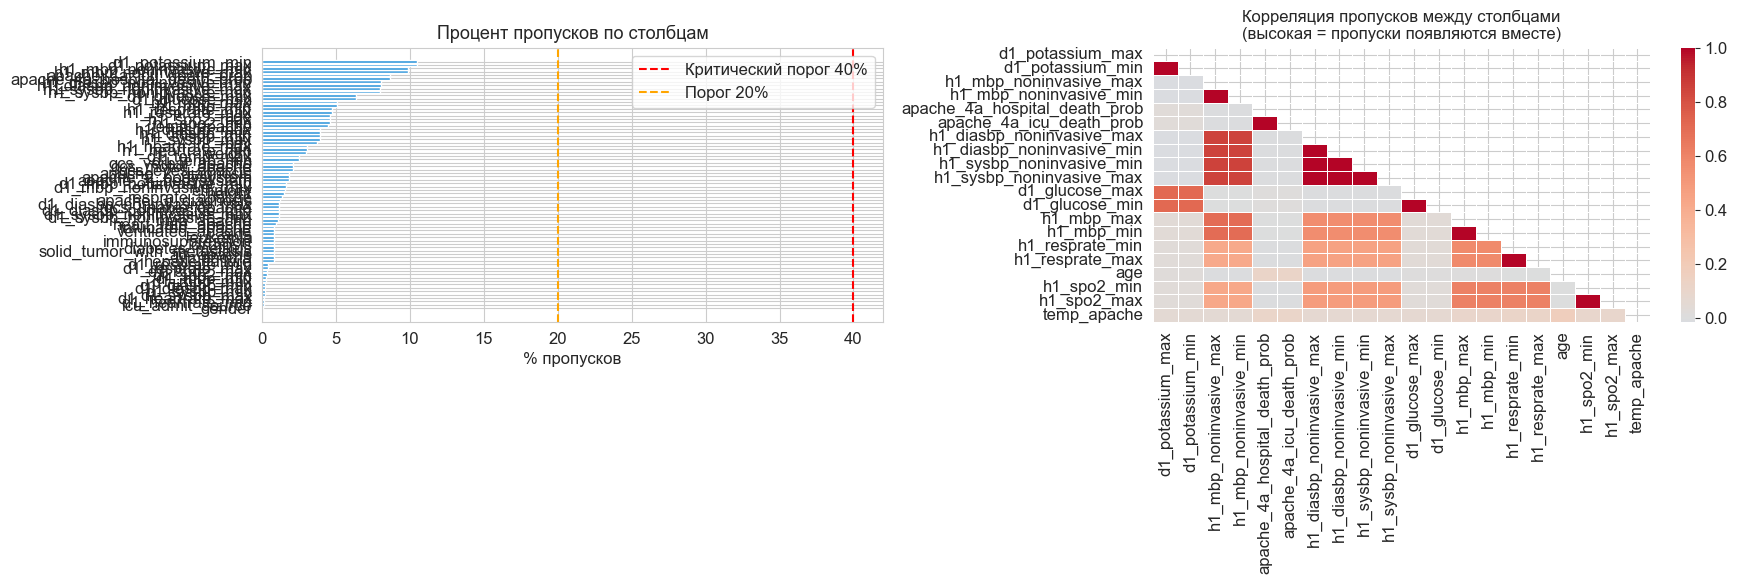

In [17]:
# Матрица пропусков (missingno)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

cols_with_missing = missing.index.tolist()

# Bar chart пропусков
missing_sorted = missing.sort_values('Процент (%)', ascending=True)
colors_bar = ['#e74c3c' if p > 40 else '#f39c12' if p > 20 else '#3498db'
              for p in missing_sorted['Процент (%)']]
axes[0].barh(missing_sorted.index, missing_sorted['Процент (%)'], color=colors_bar)
axes[0].axvline(x=40, color='red', linestyle='--', label='Критический порог 40%')
axes[0].axvline(x=20, color='orange', linestyle='--', label='Порог 20%')
axes[0].set_xlabel('% пропусков')
axes[0].set_title('Процент пропусков по столбцам', fontsize=13)
axes[0].legend()

# Тепловая карта корреляции пропусков
if len(cols_with_missing) >= 2:
    miss_corr = df[cols_with_missing[:20]].isnull().corr()
    mask = np.triu(np.ones_like(miss_corr, dtype=bool))
    sns.heatmap(miss_corr, mask=mask, cmap='coolwarm', center=0, ax=axes[1],
                annot=len(cols_with_missing) <= 15, fmt='.2f', linewidths=0.5)
    axes[1].set_title('Корреляция пропусков между столбцами\n(высокая = пропуски появляются вместе)', fontsize=12)

plt.tight_layout()
plt.show()

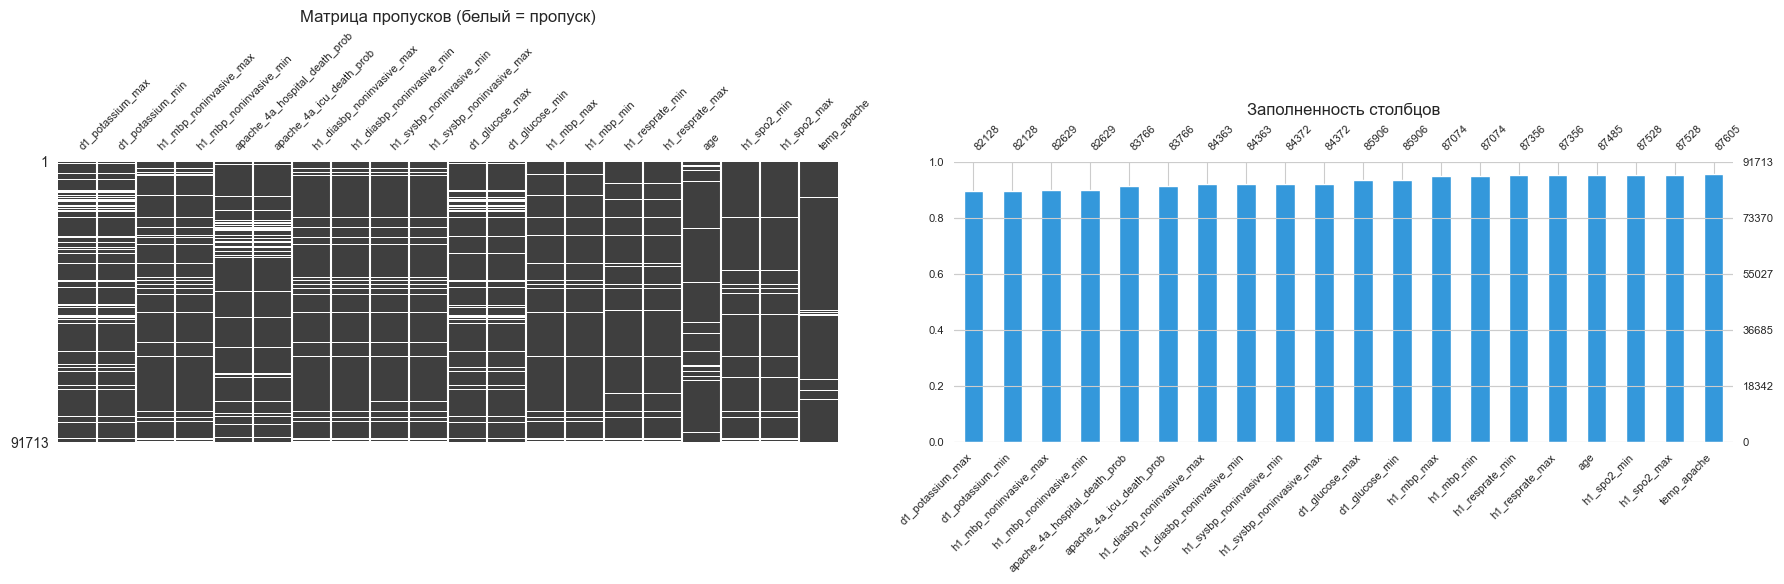

Белые полосы в матрице = пропущенные значения


In [18]:
# Матрица missingno (визуализация паттернов пропусков)
if len(cols_with_missing) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    
    # Выбираем первые 20 столбцов с пропусками для читаемости
    sample_cols = cols_with_missing[:20]
    
    msno.matrix(df[sample_cols], ax=axes[0], sparkline=False, fontsize=8)
    axes[0].set_title('Матрица пропусков (белый = пропуск)', fontsize=12)
    
    msno.bar(df[sample_cols], ax=axes[1], fontsize=8, color='#3498db')
    axes[1].set_title('Заполненность столбцов', fontsize=12)
    
    plt.tight_layout()
    plt.show()
    print('Белые полосы в матрице = пропущенные значения')

In [19]:
# Связь пропусков с целевой переменной
# Если пациент умер, чаще ли пропуски в измерениях?
miss_by_target = {}
for col in cols_with_missing[:15]:
    miss_by_target[col] = {
        'Выжившие (% пропусков)': df[df[target]==0][col].isna().mean()*100,
        'Умершие (% пропусков)': df[df[target]==1][col].isna().mean()*100
    }

miss_target_df = pd.DataFrame(miss_by_target).T.round(2)
print('Пропуски по группам (умершие vs выжившие):')
display(miss_target_df)
print('\nЕсли разница велика — пропуски систематические (MNAR) и могут нести предсказательную силу')

Пропуски по группам (умершие vs выжившие):


,Выжившие (% пропусков),Умершие (% пропусков)
d1_potassium_max,10.49,10.04
d1_potassium_min,10.49,10.04
h1_mbp_noninvasive_max,10.17,7.11
h1_mbp_noninvasive_min,10.17,7.11
apache_4a_hospital_death_prob,8.82,6.97
apache_4a_icu_death_prob,8.82,6.97
h1_diasbp_noninvasive_max,8.21,5.94
h1_diasbp_noninvasive_min,8.21,5.94
h1_sysbp_noninvasive_min,8.20,5.94
h1_sysbp_noninvasive_max,8.20,5.94



Если разница велика — пропуски систематические (MNAR) и могут нести предсказательную силу


## 6. Анализ выбросов (экстремальные значения)

In [20]:
# Клинически важные числовые столбцы для анализа выбросов
vital_cols = [
    'age', 'bmi', 'height', 'weight',
    'd1_heartrate_max', 'd1_heartrate_min',
    'd1_sysbp_max', 'd1_sysbp_min',
    'd1_diasbp_max', 'd1_diasbp_min',
    'd1_temp_max', 'd1_temp_min',
    'd1_resprate_max', 'd1_resprate_min',
    'd1_spo2_max', 'd1_spo2_min',
    'd1_glucose_max', 'd1_glucose_min',
    'd1_potassium_max', 'd1_potassium_min',
    'heart_rate_apache', 'temp_apache', 'map_apache'
]
vital_cols = [c for c in vital_cols if c in df.columns]

print(f'Анализируем {len(vital_cols)} числовых столбцов на выбросы')

Анализируем 23 числовых столбцов на выбросы


In [21]:
# Метод IQR для обнаружения выбросов
def detect_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = series[(series < lower) | (series > upper)]
    return len(outliers), lower, upper, series.min(), series.max()

# Метод Z-score
def detect_outliers_zscore(series, threshold=3):
    z_scores = np.abs(stats.zscore(series.dropna()))
    return (z_scores > threshold).sum()

outlier_report = []
for col in vital_cols:
    if df[col].dtype in ['float64', 'int64']:
        n_out, low, high, vmin, vmax = detect_outliers_iqr(df[col].dropna())
        n_zscore = detect_outliers_zscore(df[col])
        pct_out = n_out / df[col].notna().sum() * 100
        outlier_report.append({
            'Столбец': col,
            'Мин': round(vmin, 2),
            'Макс': round(vmax, 2),
            'IQR-нижняя граница': round(low, 2),
            'IQR-верхняя граница': round(high, 2),
            'Выбросов (IQR)': n_out,
            '% выбросов': round(pct_out, 2),
            'Выбросов (|z|>3)': n_zscore
        })

outlier_df = pd.DataFrame(outlier_report).set_index('Столбец')
outlier_df_sorted = outlier_df.sort_values('% выбросов', ascending=False)
print('Отчёт о выбросах (IQR-метод):')
display(outlier_df_sorted)

Отчёт о выбросах (IQR-метод):


,Мин,Макс,IQR-нижняя граница,IQR-верхняя граница,Выбросов (IQR),% выбросов,Выбросов (|z|>3)
Столбец,,,,,,,
d1_spo2_max,0.00,100.00,97.50,101.50,9262,10.14,595
temp_apache,32.10,39.70,35.45,37.45,8762,10.00,3005
d1_temp_min,31.89,37.80,35.26,37.50,6216,6.95,1971
d1_spo2_min,0.00,100.00,80.00,104.00,5973,6.54,1734
d1_glucose_max,73.00,611.00,-9.00,327.00,5390,6.27,1866
d1_temp_max,35.10,39.90,35.85,38.65,5572,6.23,1911
d1_resprate_min,0.00,100.00,1.00,25.00,4754,5.21,462
d1_resprate_max,14.00,92.00,7.00,47.00,4638,5.08,1894
d1_glucose_min,33.00,288.00,31.00,191.00,3782,4.40,1512


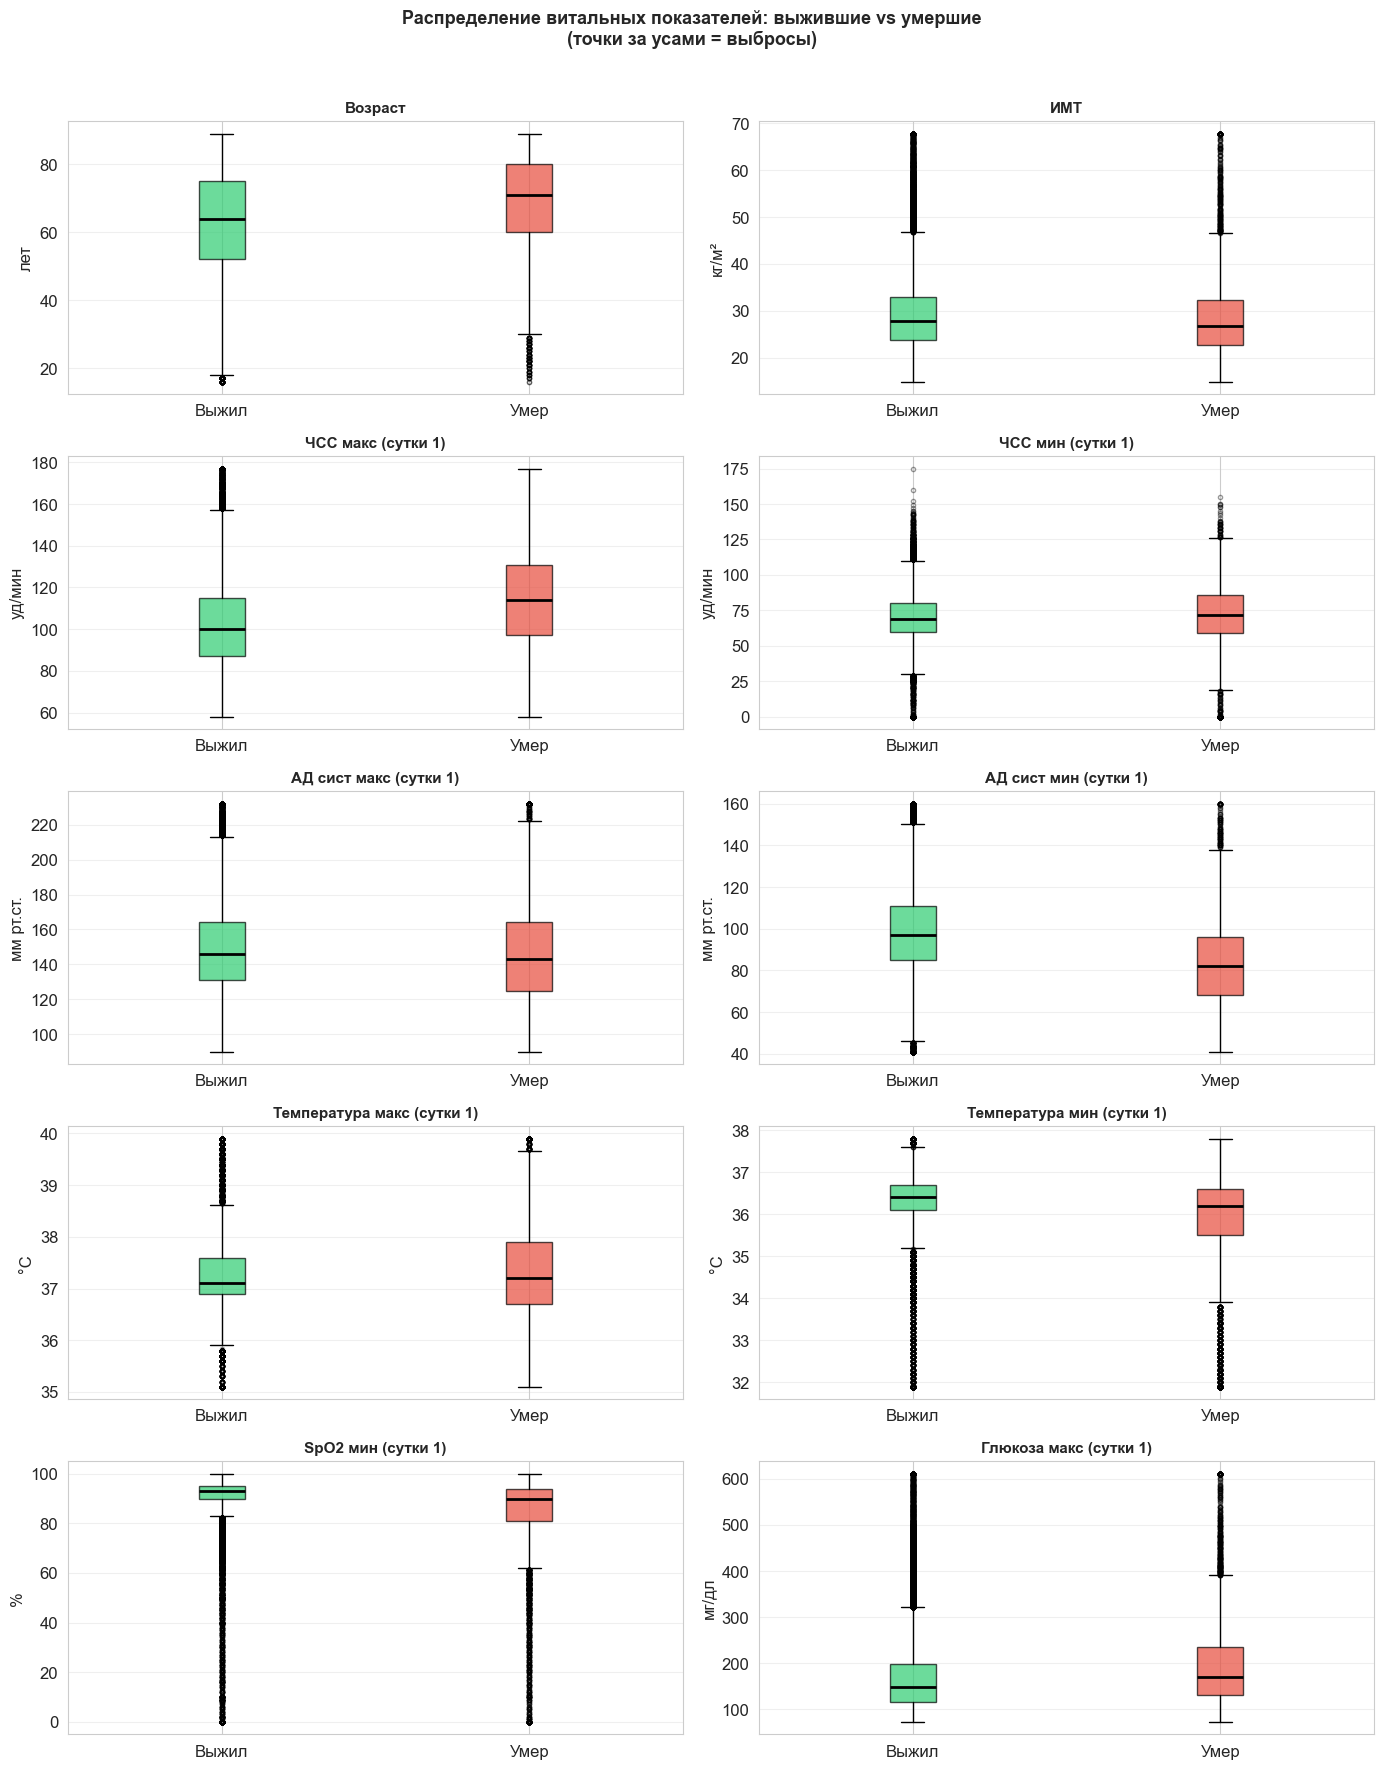

In [22]:
# Визуализация выбросов — Box plots для витальных показателей
key_vitals = [
    ('age', 'Возраст', 'лет'),
    ('bmi', 'ИМТ', 'кг/м²'),
    ('d1_heartrate_max', 'ЧСС макс (сутки 1)', 'уд/мин'),
    ('d1_heartrate_min', 'ЧСС мин (сутки 1)', 'уд/мин'),
    ('d1_sysbp_max', 'АД сист макс (сутки 1)', 'мм рт.ст.'),
    ('d1_sysbp_min', 'АД сист мин (сутки 1)', 'мм рт.ст.'),
    ('d1_temp_max', 'Температура макс (сутки 1)', '°C'),
    ('d1_temp_min', 'Температура мин (сутки 1)', '°C'),
    ('d1_spo2_min', 'SpO2 мин (сутки 1)', '%'),
    ('d1_glucose_max', 'Глюкоза макс (сутки 1)', 'мг/дл'),
]
key_vitals = [(c, lbl, unit) for c, lbl, unit in key_vitals if c in df.columns]

n_plots = len(key_vitals)
n_cols = 2
n_rows = (n_plots + 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 3.5))
axes = axes.flatten()

for idx, (col, label, unit) in enumerate(key_vitals):
    ax = axes[idx]
    data_survived = df[df[target]==0][col].dropna()
    data_died = df[df[target]==1][col].dropna()
    
    bp = ax.boxplot([data_survived, data_died],
                    labels=['Выжил', 'Умер'],
                    patch_artist=True,
                    medianprops={'color': 'black', 'linewidth': 2},
                    flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.4})
    bp['boxes'][0].set_facecolor('#2ecc71')
    bp['boxes'][0].set_alpha(0.7)
    if len(bp['boxes']) > 1:
        bp['boxes'][1].set_facecolor('#e74c3c')
        bp['boxes'][1].set_alpha(0.7)
    
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_ylabel(unit)
    ax.grid(axis='y', alpha=0.3)

# Скрываем лишние оси
for idx in range(n_plots, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Распределение витальных показателей: выжившие vs умершие\n(точки за усами = выбросы)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [24]:
# Клинически невозможные значения (жёсткие границы)
clinical_bounds = {
    'age': (0, 130, 'лет'),
    'bmi': (10, 100, 'кг/м²'),
    'height': (100, 250, 'см'),
    'weight': (20, 400, 'кг'),
    'd1_heartrate_max': (10, 300, 'уд/мин'),
    'd1_heartrate_min': (10, 300, 'уд/мин'),
    'd1_sysbp_max': (50, 300, 'мм рт.ст.'),
    'd1_sysbp_min': (20, 300, 'мм рт.ст.'),
    'd1_temp_max': (25, 45, '°C'),
    'd1_temp_min': (25, 45, '°C'),
    'd1_spo2_max': (50, 100, '%'),
    'd1_spo2_min': (50, 100, '%'),
    'd1_resprate_max': (4, 80, 'вд/мин'),
    'd1_resprate_min': (4, 80, 'вд/мин'),
}

print('Клинически невозможные значения:')
print('-' * 60)
anomaly_found = False
for col, (low, high, unit) in clinical_bounds.items():
    if col in df.columns:
        n_below = (df[col] < low).sum()
        n_above = (df[col] > high).sum()
        if n_below > 0 or n_above > 0:
            print(f'  {col} [{low}, {high}] {unit}:')
            if n_below > 0:
                print(f'    Ниже нормы: {n_below} значений (мин={df[col].min():.1f})')
            if n_above > 0:
                print(f'    Выше нормы: {n_above} значений (макс={df[col].max():.1f})')
            anomaly_found = True

if not anomaly_found:
    print('Клинически невозможных значений не обнаружено.')

Клинически невозможные значения:
------------------------------------------------------------
  d1_heartrate_min [10, 300] уд/мин:
    Ниже нормы: 652 значений (мин=0.0)
  d1_spo2_max [50, 100] %:
    Ниже нормы: 12 значений (мин=0.0)
  d1_spo2_min [50, 100] %:
    Ниже нормы: 1116 значений (мин=0.0)
  d1_resprate_max [4, 80] вд/мин:
    Выше нормы: 737 значений (макс=92.0)
  d1_resprate_min [4, 80] вд/мин:
    Ниже нормы: 4516 значений (мин=0.0)
    Выше нормы: 2 значений (макс=100.0)


## 7. Анализ числовых переменных

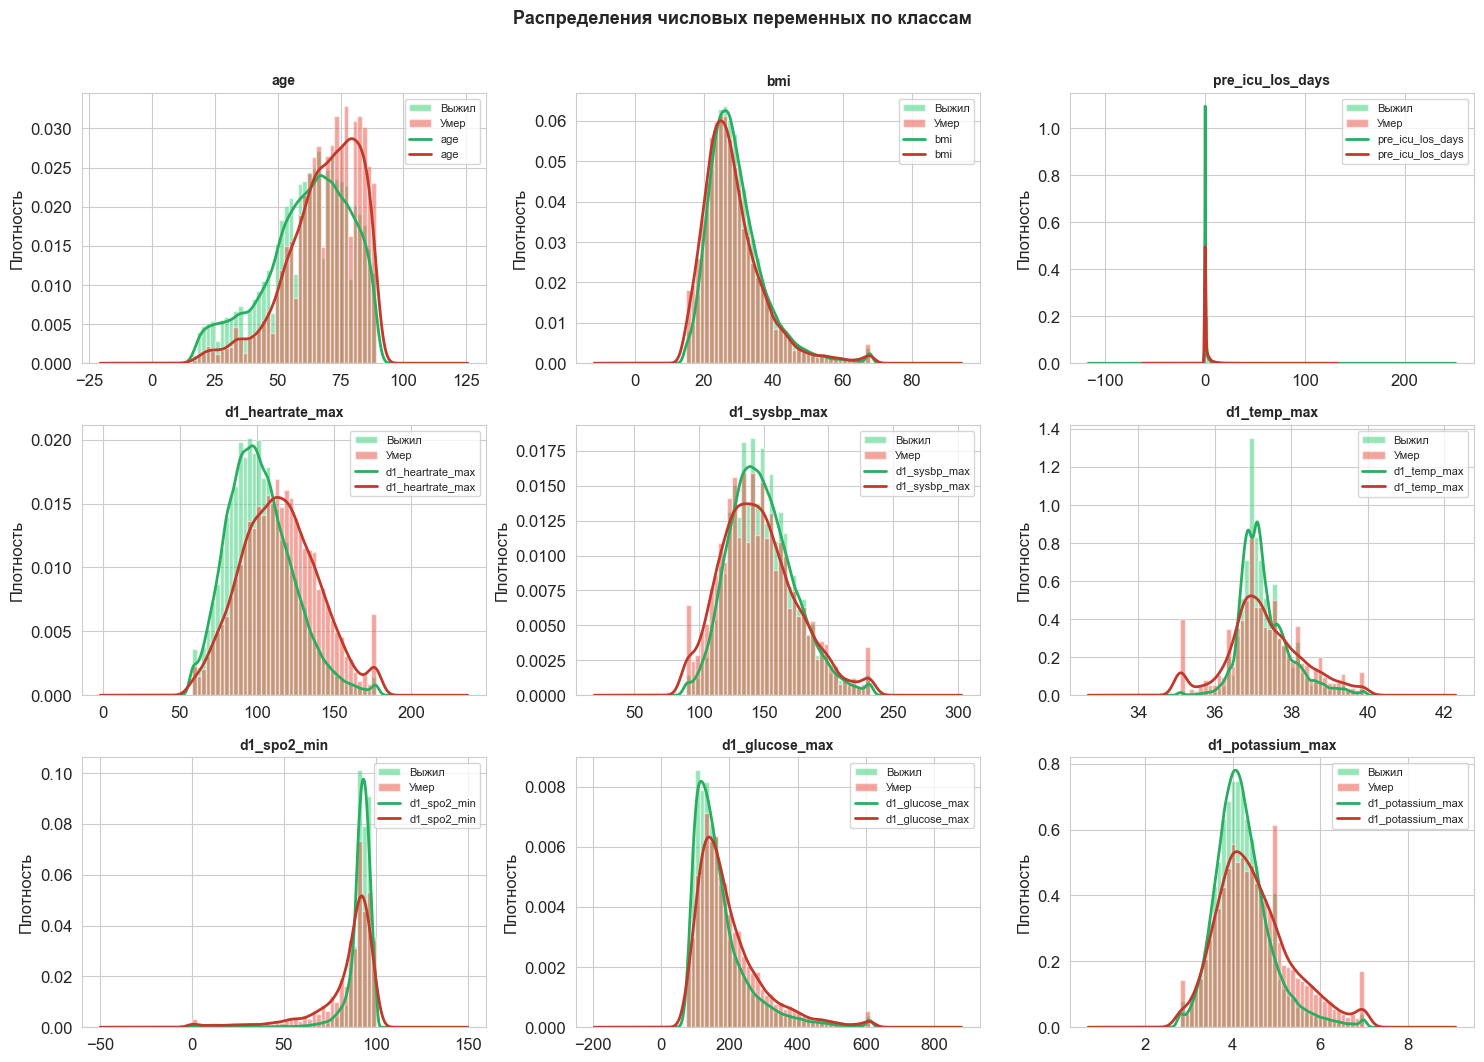

In [25]:
# Гистограммы + KDE ключевых числовых переменных
hist_cols = ['age', 'bmi', 'pre_icu_los_days',
             'd1_heartrate_max', 'd1_sysbp_max', 'd1_temp_max',
             'd1_spo2_min', 'd1_glucose_max', 'd1_potassium_max']
hist_cols = [c for c in hist_cols if c in df.columns]

n_cols = 3
n_rows = (len(hist_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3.5))
axes = axes.flatten()

for idx, col in enumerate(hist_cols):
    ax = axes[idx]
    survived = df[df[target]==0][col].dropna()
    died = df[df[target]==1][col].dropna()
    
    ax.hist(survived, bins=40, alpha=0.5, color='#2ecc71', label='Выжил', density=True)
    ax.hist(died, bins=40, alpha=0.5, color='#e74c3c', label='Умер', density=True)
    
    # KDE
    try:
        survived.plot.kde(ax=ax, color='#27ae60', linewidth=2)
        died.plot.kde(ax=ax, color='#c0392b', linewidth=2)
    except Exception:
        pass
    
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.legend(fontsize=8)
    ax.set_ylabel('Плотность')

for idx in range(len(hist_cols), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Распределения числовых переменных по классам', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

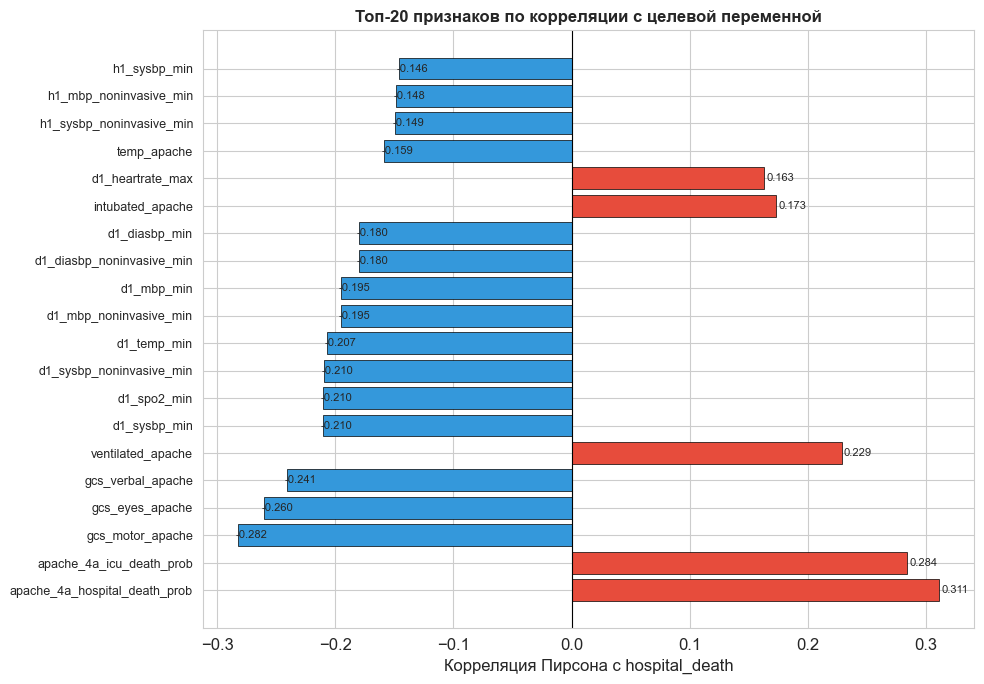

In [26]:
# Матрица корреляций (числовые столбцы)
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Берём корреляцию с целевой переменной
corr_with_target = df[num_cols].corr()[target].drop(target).sort_values(key=abs, ascending=False)

top_corr = corr_with_target.head(20)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#e74c3c' if v > 0 else '#3498db' for v in top_corr.values]
bars = ax.barh(range(len(top_corr)), top_corr.values, color=colors, edgecolor='black', linewidth=0.5)
ax.set_yticks(range(len(top_corr)))
ax.set_yticklabels(top_corr.index, fontsize=9)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Корреляция Пирсона с hospital_death')
ax.set_title('Топ-20 признаков по корреляции с целевой переменной', fontsize=12, fontweight='bold')
for i, v in enumerate(top_corr.values):
    ax.text(v + 0.002 * np.sign(v), i, f'{v:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

## 8. Анализ категориальных переменных

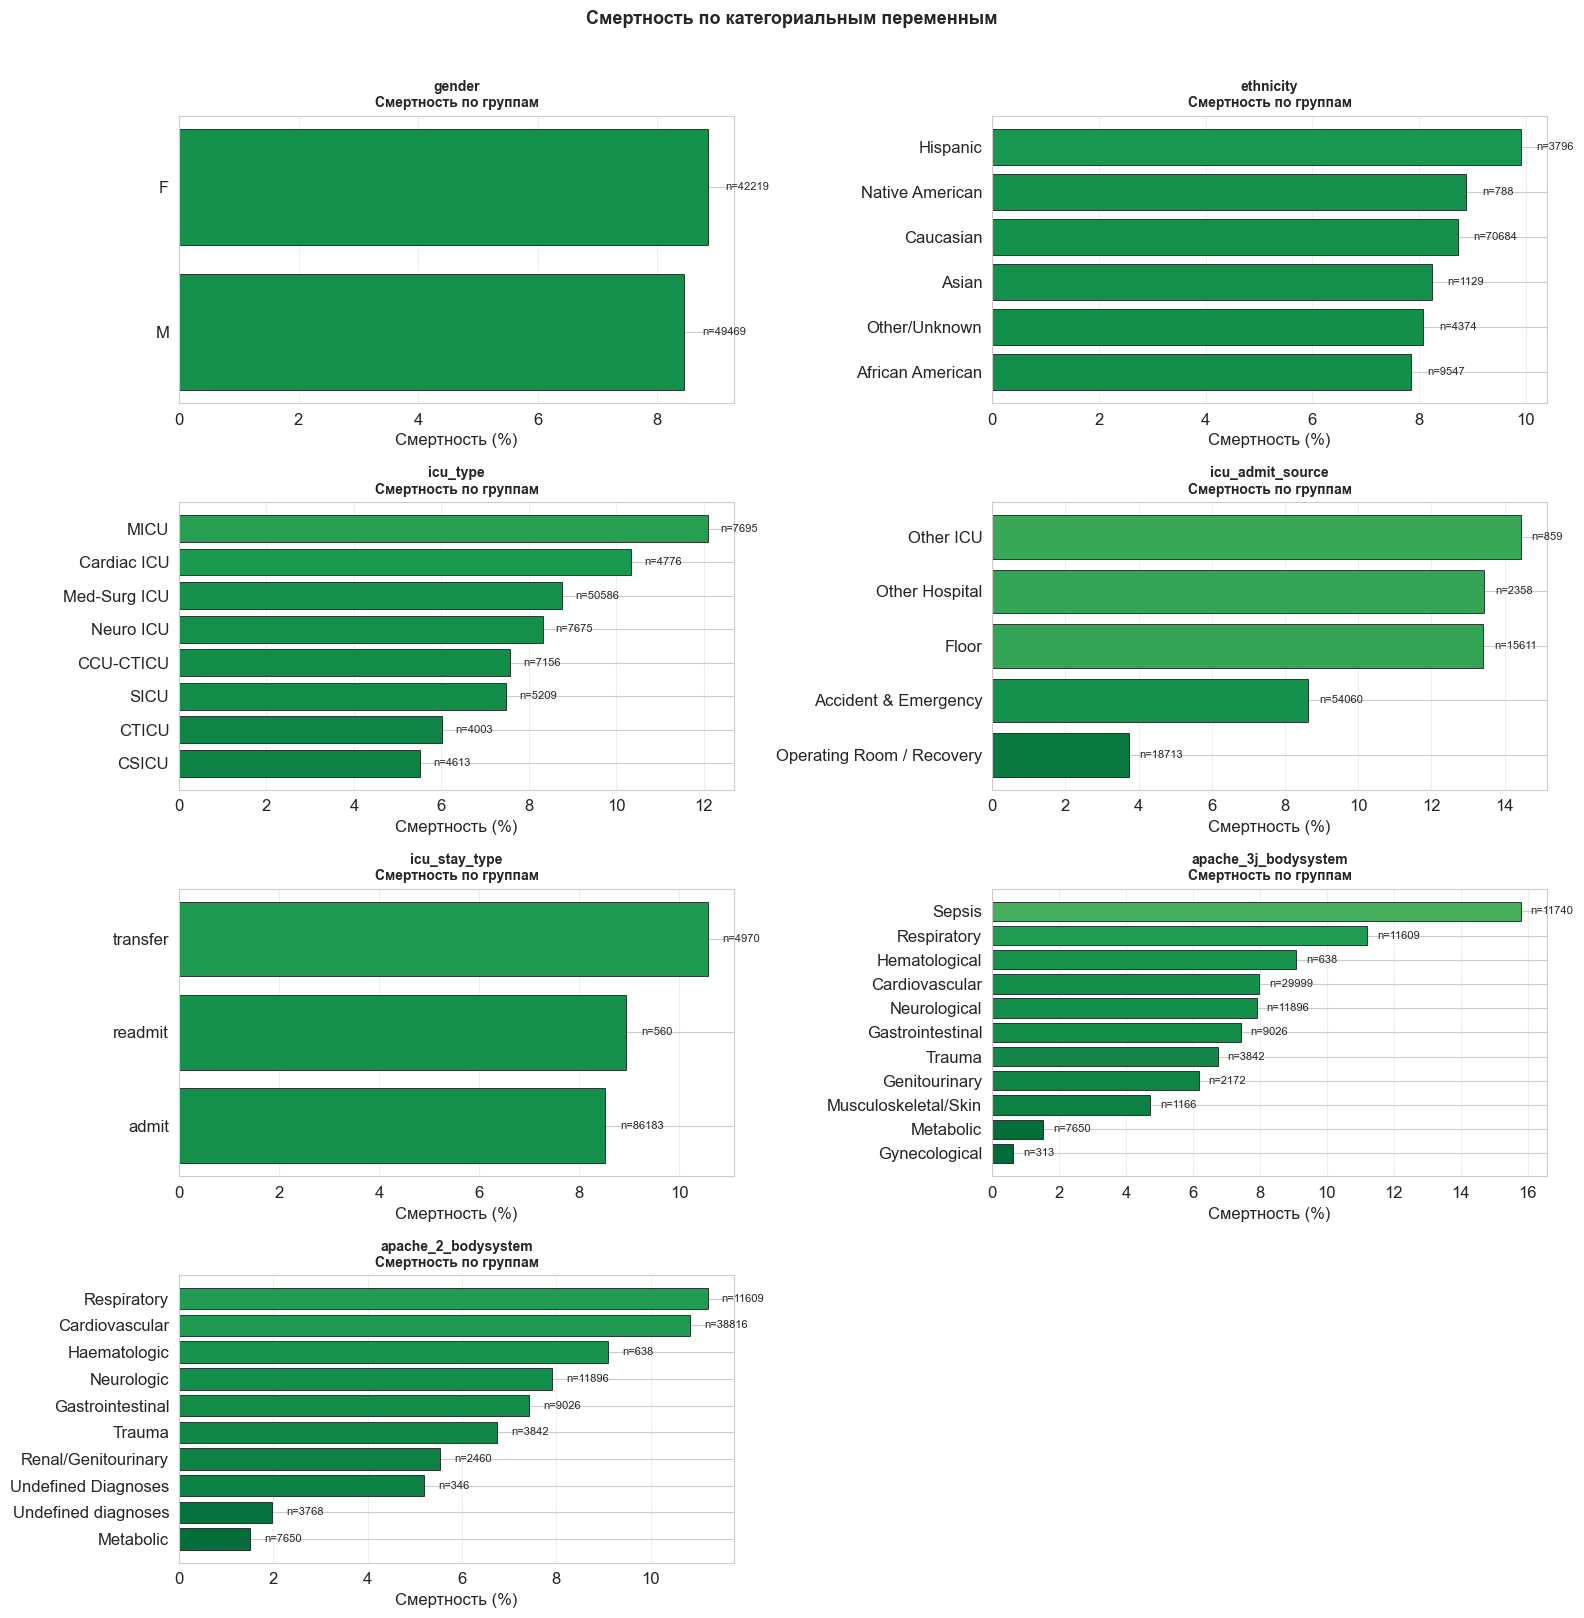

In [27]:
cat_cols = ['gender', 'ethnicity', 'icu_type', 'icu_admit_source', 'icu_stay_type',
            'apache_3j_bodysystem', 'apache_2_bodysystem']
cat_cols = [c for c in cat_cols if c in df.columns]

n_cols = 2
n_rows = (len(cat_cols) + 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for idx, col in enumerate(cat_cols):
    ax = axes[idx]
    # Смертность по категории
    group = df.groupby(col)[target].agg(['mean', 'count']).reset_index()
    group.columns = [col, 'Смертность', 'Кол-во']
    group = group.dropna().sort_values('Смертность', ascending=True)
    
    bars = ax.barh(group[col].astype(str), group['Смертность'] * 100,
                   color=plt.cm.RdYlGn_r(group['Смертность'].values),
                   edgecolor='black', linewidth=0.5)
    
    # Подписи с количеством
    for bar, cnt in zip(bars, group['Кол-во']):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f'n={cnt}', va='center', fontsize=8)
    
    ax.set_xlabel('Смертность (%)')
    ax.set_title(f'{col}\nСмертность по группам', fontsize=10, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)

for idx in range(len(cat_cols), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Смертность по категориальным переменным', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 9. Анализ бинарных признаков (коморбидности)

In [28]:
comorbidity_cols = ['aids', 'cirrhosis', 'diabetes_mellitus', 'hepatic_failure',
                    'immunosuppression', 'leukemia', 'lymphoma', 'solid_tumor_with_metastasis',
                    'elective_surgery', 'apache_post_operative', 'arf_apache',
                    'intubated_apache', 'ventilated_apache']
comorbidity_cols = [c for c in comorbidity_cols if c in df.columns]

# Распространённость и смертность
comor_stats = []
for col in comorbidity_cols:
    prevalence = df[col].mean() * 100
    mortality_with = df[df[col]==1][target].mean() * 100
    mortality_without = df[df[col]==0][target].mean() * 100
    comor_stats.append({
        'Признак': col,
        'Распространённость (%)': round(prevalence, 2),
        'Смертность при наличии (%)': round(mortality_with, 2),
        'Смертность при отсутствии (%)': round(mortality_without, 2),
        'Разница (%)': round(mortality_with - mortality_without, 2)
    })

comor_df = pd.DataFrame(comor_stats).set_index('Признак').sort_values('Разница (%)', ascending=False)
print('Статистика бинарных признаков:')
display(comor_df)

Статистика бинарных признаков:


,Распространённость (%),Смертность при наличии (%),Смертность при отсутствии (%),Разница (%)
Признак,,,,
ventilated_apache,32.57,17.83,4.15,13.68
intubated_apache,15.12,20.11,6.56,13.55
solid_tumor_with_metastasis,2.06,18.48,8.40,10.08
leukemia,0.71,18.51,8.53,9.97
hepatic_failure,1.30,18.10,8.48,9.63
cirrhosis,1.57,17.37,8.46,8.90
lymphoma,0.41,16.76,8.57,8.18
immunosuppression,2.62,16.13,8.40,7.73
arf_apache,2.80,13.12,8.47,4.64


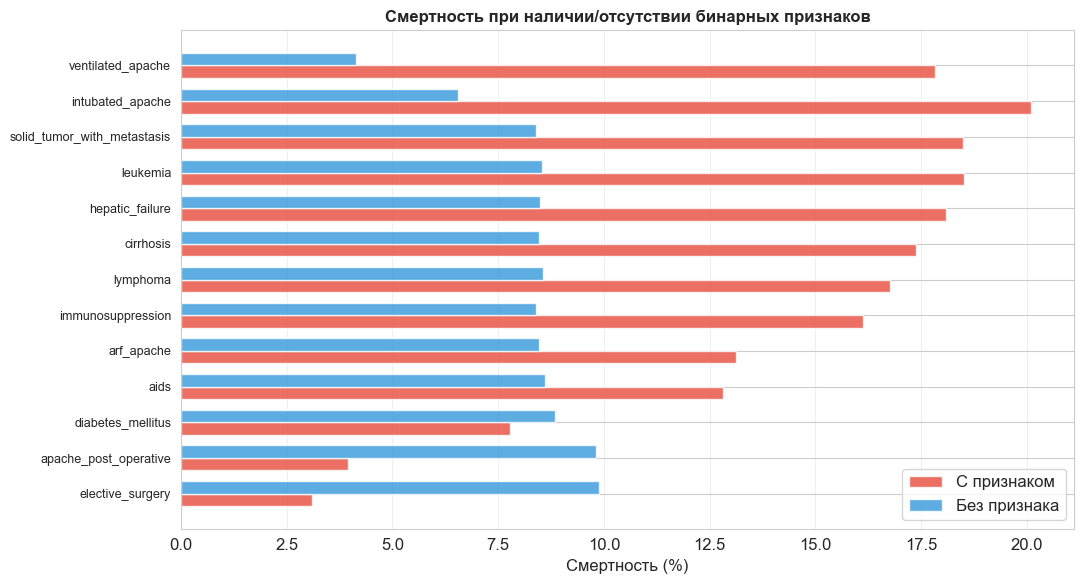

In [29]:
# Визуализация — смертность по коморбидностям
fig, ax = plt.subplots(figsize=(11, 6))

comor_sorted = comor_df.sort_values('Разница (%)')
x = range(len(comor_sorted))
width = 0.35

ax.barh([i - width/2 for i in x], comor_sorted['Смертность при наличии (%)'],
        width, label='С признаком', color='#e74c3c', alpha=0.8)
ax.barh([i + width/2 for i in x], comor_sorted['Смертность при отсутствии (%)'],
        width, label='Без признака', color='#3498db', alpha=0.8)

ax.set_yticks(x)
ax.set_yticklabels(comor_sorted.index, fontsize=9)
ax.set_xlabel('Смертность (%)')
ax.set_title('Смертность при наличии/отсутствии бинарных признаков', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Проверка apache_4a_*_death_prob (возможная утечка данных)

Эти столбцы содержат уже готовые предсказания вероятности смерти.  
Использование их как признаков в модели - **утечка данных**.

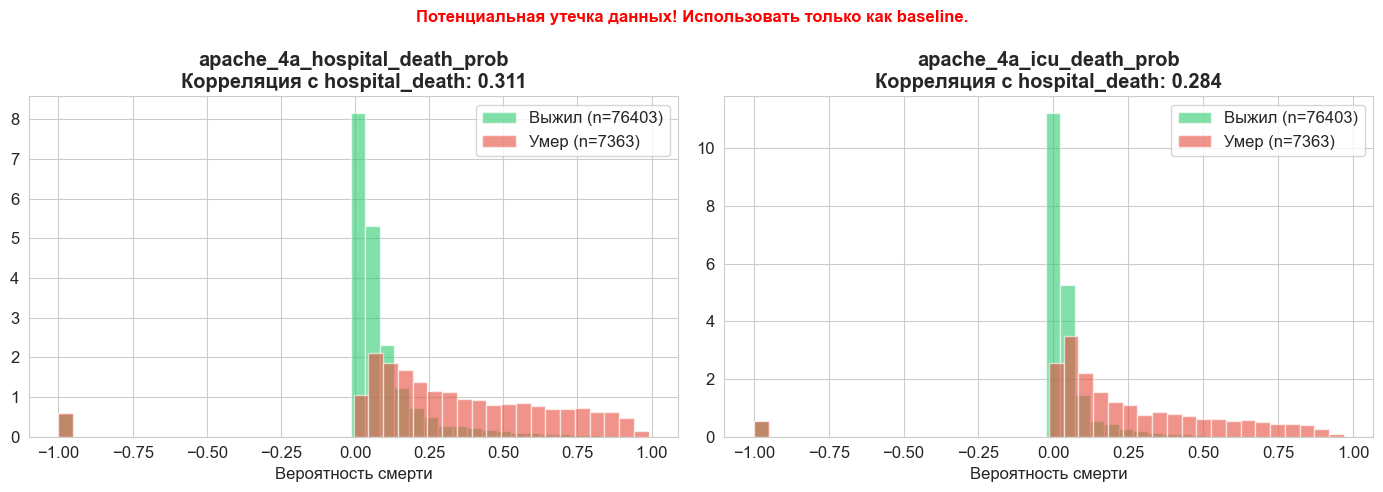

In [31]:
leakage_cols = ['apache_4a_hospital_death_prob', 'apache_4a_icu_death_prob']
leakage_cols = [c for c in leakage_cols if c in df.columns]

if leakage_cols:
    fig, axes = plt.subplots(1, len(leakage_cols), figsize=(14, 5))
    if len(leakage_cols) == 1:
        axes = [axes]
    
    for ax, col in zip(axes, leakage_cols):
        survived = df[df[target]==0][col].dropna()
        died = df[df[target]==1][col].dropna()
        ax.hist(survived, bins=40, alpha=0.6, color='#2ecc71', label=f'Выжил (n={len(survived)})', density=True)
        ax.hist(died, bins=40, alpha=0.6, color='#e74c3c', label=f'Умер (n={len(died)})', density=True)
        corr_val = df[col].corr(df[target])
        ax.set_title(f'{col}\nКорреляция с hospital_death: {corr_val:.3f}', fontweight='bold')
        ax.set_xlabel('Вероятность смерти')
        ax.legend()
    
    plt.suptitle('Потенциальная утечка данных! Использовать только как baseline.',
                 fontsize=12, color='red', fontweight='bold')
    plt.tight_layout()
    plt.show()

## 11. Итоговый отчёт о качестве данных

In [37]:
print('Итоговый отчёт о качестве данных')

print(f'\n Общая информация')
print(f'  Строк: {df.shape[0]:,}, столбцов: {df.shape[1]}')
death_rate = df[target].mean()*100
print(f'  Смертность: {death_rate:.1f}% - ', end='')
print('Дисбаланс классов!' if death_rate < 20 else 'баланс приемлемый')

print(f'\n Пропуски')
high_miss = missing[missing['Процент (%)'] > 40]
med_miss = missing[(missing['Процент (%)'] > 20) & (missing['Процент (%)'] <= 40)]
low_miss = missing[(missing['Процент (%)'] > 0) & (missing['Процент (%)'] <= 20)]
print(f'  Критические (>40%): {len(high_miss)} столбцов - рассмотреть удаление')
if len(high_miss) > 0:
    for col in high_miss.index:
        print(f'    - {col}: {high_miss.loc[col, "Процент (%)"]}%')
print(f'  Значимые (20-40%): {len(med_miss)} столбцов - модельная импутация (KNN/MICE)')
print(f'  Небольшие (<20%): {len(low_miss)} столбцов - медиана/среднее')

print(f'\n  Выбросы')
high_outliers = outlier_df_sorted[outlier_df_sorted['% выбросов'] > 5]
print(f'  Столбцов с >5% выбросов (IQR): {len(high_outliers)}')
for col in high_outliers.index:
    print(f'    - {col}: {high_outliers.loc[col, "% выбросов"]}%')

print(f'\n Утечка данных')
print(f'  Столбцы: apache_4a_hospital_death_prob, apache_4a_icu_death_prob')
print(f'  Исключить из признаков! Использовать только как baseline.')

print(f'\n  Лишние столбцы')
print(f'  - Unnamed: 83 (удалён)')
print(f'  - encounter_id, patient_id, hospital_id, icu_id - идентификаторы, не признаки')

print(f'\n Рекомендации перед моделированием')
recommendations = [
    'Удалить столбцы с >40% пропусков или применить специальные техники',
    'Заполнить пропуски: медиана для числовых, мода для категориальных',
    'Рассмотреть добавление бинарных признаков-индикаторов пропусков',
    'Обработать выбросы: клиппинг по IQR или клиническим границам',
    'Закодировать категориальные: LabelEncoder / OneHotEncoder',
    'Исключить leakage-столбцы из обучения',
    'Применить балансировку: SMOTE, class_weight="balanced"',
    'Стандартизировать числовые признаки: StandardScaler / RobustScaler',
]
for i, rec in enumerate(recommendations, 1):
    print(f'  {i}. {rec}')

Итоговый отчёт о качестве данных

 Общая информация
  Строк: 91,713, столбцов: 84
  Смертность: 8.6% - Дисбаланс классов!

 Пропуски
  Критические (>40%): 0 столбцов - рассмотреть удаление
  Значимые (20-40%): 0 столбцов - модельная импутация (KNN/MICE)
  Небольшие (<20%): 74 столбцов - медиана/среднее

  Выбросы
  Столбцов с >5% выбросов (IQR): 8
    - d1_spo2_max: 10.14%
    - temp_apache: 10.0%
    - d1_temp_min: 6.95%
    - d1_spo2_min: 6.54%
    - d1_glucose_max: 6.27%
    - d1_temp_max: 6.23%
    - d1_resprate_min: 5.21%
    - d1_resprate_max: 5.08%

 Утечка данных
  Столбцы: apache_4a_hospital_death_prob, apache_4a_icu_death_prob
  Исключить из признаков! Использовать только как baseline.

  Лишние столбцы
  - Unnamed: 83 (удалён)
  - encounter_id, patient_id, hospital_id, icu_id - идентификаторы, не признаки

 Рекомендации перед моделированием
  1. Удалить столбцы с >40% пропусков или применить специальные техники
  2. Заполнить пропуски: медиана для числовых, мода для категори